<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_2_2_%D0%9D%D0%B5%D0%B7%D0%B1%D0%B0%D0%BB%D0%B0%D0%BD%D1%81%D0%BE%D0%B2%D0%B0%D0%BD%D0%B0_%D0%B1%D0%B0%D0%B3%D0%B0%D1%82%D0%BE%D0%BA%D0%BB%D0%B0%D1%81%D0%BE%D0%B2%D0%B0_%D0%BA%D0%BB%D0%B0%D1%81%D0%B8%D1%84%D1%96%D0%BA%D0%B0%D1%86%D1%96%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [1]:
!pip -q install gdown
!pip -q install imbalanced-learn

In [40]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_curve, auc, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTETomek
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

In [3]:
url_application_data_csv_zip = 'https://drive.google.com/file/d/1-R-tjuj-KiQRSC5wyCXzKIDssUPvUSJN/view?usp=sharing'

gdown.download(url_application_data_csv_zip, "customer_segmentation_train.csv", fuzzy=True)

customer_df = pd.read_csv('customer_segmentation_train.csv')

Downloading...
From: https://drive.google.com/uc?id=1-R-tjuj-KiQRSC5wyCXzKIDssUPvUSJN
To: /content/customer_segmentation_train.csv
100%|██████████| 425k/425k [00:00<00:00, 54.6MB/s]


In [4]:
customer_df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


#0 Попередній аналіз даних


In [5]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [6]:
customer_df.shape

(8068, 11)

In [7]:
customer_df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [8]:
len(customer_df.select_dtypes(include = "object").columns)

7

In [9]:
number_df = customer_df.select_dtypes(include="number")
number_df.columns

Index(['ID', 'Age', 'Work_Experience', 'Family_Size'], dtype='object')

Датасет містить 4 цифрові колонки та 7 категоріальних. Дані виглядають адекватними, але є пропущені значення

In [10]:
#перевірка на наявність пропущених значень
customer_df.isnull().values.any()

np.True_

In [11]:
customer_df.columns[customer_df.isnull().any()]

Index(['Ever_Married', 'Graduated', 'Profession', 'Work_Experience',
       'Family_Size', 'Var_1'],
      dtype='object')

In [12]:
null_count = customer_df.isnull().sum()
null_percentage = round((customer_df.isnull().sum()/customer_df.shape[0])*100, 2)

In [13]:
null_percentage

,0
ID,0.00
Gender,0.00
Ever_Married,1.74
Age,0.00
Graduated,0.97
Profession,1.54
Work_Experience,10.28
Spending_Score,0.00
Family_Size,4.15
Var_1,0.94


In [14]:
customer_df.groupby(customer_df['Work_Experience'].isna())['Segmentation'].value_counts(normalize=True)

Work_Experience  Segmentation
False            D               0.273518
                 C               0.250725
                 A               0.245614
                 B               0.230142
True             D               0.347407
                 A               0.234017
                 B               0.231604
                 C               0.186972
Name: proportion, dtype: float64

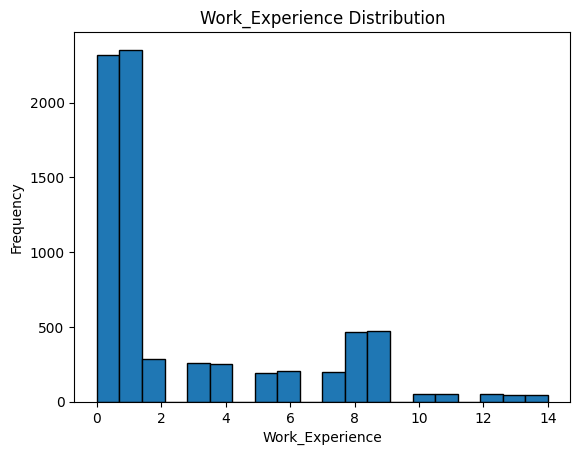

In [15]:
customer_df['Work_Experience'].dropna().plot(kind='hist', bins=20, edgecolor='black')
plt.title('Work_Experience Distribution')
plt.xlabel('Work_Experience')
plt.ylabel('Frequency')
plt.show()

Коментар: так як кількість пропущених значень невелика і в цілому значень для аналізу не так багато, краще не видаляти колонки, а доповнити

Ever_Married, Graduated, Var_1, Family_Size -  -  я заповню модою

Profession - незаповнене можна заповнити Unknown
Work_Experience - заповню медіаною, тому що розподіл дуже скошений

In [16]:
#проведемо імпутацію даних в колонки 'Ever_Married', 'Graduated', 'Var_1', 'Family_Size'
for col in ['Ever_Married', 'Graduated', 'Var_1', 'Family_Size']:
  customer_df.fillna({col: (customer_df[col].mode()[0])}, inplace=True)

#проведемо імпутацію даних в колонку Profession
customer_df.fillna({'Profession':'Unknown'}, inplace=True)

#проведемо імпутацію даних в колонку Work_Experience, зі створення додаткової прапорцевої колонки

customer_df['Work_Experience_missing'] = customer_df['Work_Experience'].isna().astype(int)
customer_df.fillna({'Work_Experience': (customer_df[col].median())}, inplace=True)



In [17]:
customer_df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Work_Experience_missing
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D,0
1,462643,Female,Yes,38,Yes,Engineer,2.0,Average,3.0,Cat_4,A,1
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B,0
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B,0
4,462669,Female,Yes,40,Yes,Entertainment,2.0,High,6.0,Cat_6,A,1
...,...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,Unknown,0.0,Low,7.0,Cat_1,D,0
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D,0
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D,0
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B,0


#1 Розділяємо датасет на траенувальний та валідаційний

In [18]:
# Створюємо трен. і вал. набори
train_data, val_data = train_test_split(customer_df, test_size=0.2, random_state=42, stratify = customer_df['Segmentation'])

inp_cols = list(customer_df.drop(['ID','Segmentation'], axis=1).columns)
tar_col = 'Segmentation'

train_inputs, train_targets = train_data[inp_cols].copy(), train_data[tar_col].copy()
val_inputs, val_targets = val_data[inp_cols].copy(), val_data[tar_col].copy()

# Виявляємо числові і категоріальні колонки

num_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
cat_cols =  train_inputs.select_dtypes('object').columns.tolist()


#preprocessing
1. Колонку ID я не включала в датасет
2. Числові колонки потребують масшатабування
3. Категоріальні колонки Gender, Ever_Married, Graduated - бінарні, тому я перетворю їх в 0 та 1
4. Категоріальні колонки Profession (10 унік.кат.) закодую OneHotEncoder, Spending_Score (3 унік.кат), Var_1 (7 унік.кат) я закодую OrdinalEncoder

In [19]:
sorted(train_inputs['Var_1'].unique())

['Cat_1', 'Cat_2', 'Cat_3', 'Cat_4', 'Cat_5', 'Cat_6', 'Cat_7']

In [20]:
# Бінарне кодування
binary_mappings = {
    'Gender':{'Male': 0, 'Female': 1},
    'Ever_Married':{'No': 0, 'Yes': 1},
    'Graduated':{'No': 0, 'Yes': 1},
}
for col, mapping in binary_mappings.items():
    #кодуємо бінарні змінні в train dataset
    train_inputs[col] = train_inputs[col].map(mapping)
    #кодуємо бінарні змінні в val dataset
    val_inputs[col] = val_inputs[col].map(mapping)

    #=====================

# кодування колонки Profession OneHotEncoder
one_hot = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot.fit_transform(train_inputs[['Profession']])

profession_encoded_cols = list(one_hot.get_feature_names_out(['Profession']))


#кодуємо Profession в train dataset
train_inputs[profession_encoded_cols] = one_hot.transform(train_inputs[['Profession']])

#кодуємо Profession в val dataset
val_inputs[profession_encoded_cols] = one_hot.transform(val_inputs[['Profession']])

#Видаляємо оригінальну колонку Profession
train_inputs = train_inputs.drop(['Profession'], axis=1)
val_inputs = val_inputs.drop(['Profession'], axis=1)

#============================

#кодування колонки Spending_Score, Var_1
ordinal = OrdinalEncoder(
    categories=[
        ['Low', 'Average', 'High'],  # Spending_Score
        ['Cat_1', 'Cat_2', 'Cat_3', 'Cat_4', 'Cat_5', 'Cat_6', 'Cat_7'],  # Var_1
    ],
    handle_unknown='use_encoded_value',
    unknown_value=-1  # NaN або невідома категорія → -1
)

#кодуємо  в train dataset
train_inputs[['Spending_Score', 'Var_1']] = ordinal.fit_transform(
    train_inputs[['Spending_Score', 'Var_1']])
#кодуємо  в val dataset
val_inputs[['Spending_Score', 'Var_1']] = ordinal.transform(
    val_inputs[['Spending_Score', 'Var_1']])

#===================
scaler = StandardScaler()

#scaler на train dataset
train_inputs[['Age', 'Work_Experience', 'Family_Size']] = scaler.fit_transform(
    train_inputs[['Age', 'Work_Experience', 'Family_Size']]
)

#scaler на val dataset
val_inputs[['Age', 'Work_Experience', 'Family_Size']] = scaler.transform(
    val_inputs[['Age', 'Work_Experience', 'Family_Size']])

In [41]:
model_original = OneVsRestClassifier(LogisticRegression(solver='liblinear', class_weight='balanced', C=0.3))
model_original.fit(train_inputs, train_targets)

OneVsRestClassifier(estimator=LogisticRegression(C=0.3, class_weight='balanced',
                                                 solver='liblinear'))

In [42]:
def predict_and_plot(model, inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    print(classification_report(targets, preds))

    return preds

In [43]:
original_train_preds = predict_and_plot(model_original,train_inputs, train_targets, name = "Training")

Accuracy: 50.88%
              precision    recall  f1-score   support

           A       0.42      0.48      0.45      1578
           B       0.40      0.22      0.28      1486
           C       0.49      0.61      0.54      1576
           D       0.66      0.68      0.67      1814

    accuracy                           0.51      6454
   macro avg       0.49      0.50      0.49      6454
weighted avg       0.50      0.51      0.50      6454



In [44]:
original_val_preds = predict_and_plot(model_original,val_inputs, val_targets, name = "Validation")

Accuracy: 51.05%
              precision    recall  f1-score   support

           A       0.40      0.45      0.43       394
           B       0.38      0.20      0.27       372
           C       0.51      0.62      0.56       394
           D       0.66      0.72      0.69       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.48      1614
weighted avg       0.50      0.51      0.50      1614



#Висновок
Базова модель лінійної регресії вийшла не дуже точна, але стабільна - на тренувальному і валідаційному датасетах різниця в accuracy до 2%
Найгірше розпізнається клас В

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [25]:
print(list(enumerate(train_inputs.columns)))

[(0, 'Gender'), (1, 'Ever_Married'), (2, 'Age'), (3, 'Graduated'), (4, 'Work_Experience'), (5, 'Spending_Score'), (6, 'Family_Size'), (7, 'Var_1'), (8, 'Work_Experience_missing'), (9, 'Profession_Artist'), (10, 'Profession_Doctor'), (11, 'Profession_Engineer'), (12, 'Profession_Entertainment'), (13, 'Profession_Executive'), (14, 'Profession_Healthcare'), (15, 'Profession_Homemaker'), (16, 'Profession_Lawyer'), (17, 'Profession_Marketing'), (18, 'Profession_Unknown')]


In [26]:
cat_feature_indices = [0, 1, 3, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

In [45]:
#Реалізація SMOTENC
#передаємо в SMOTENC, які колонки є категоріальними та робимо oversampling із SMOTE

smote_nc = SMOTENC(categorical_features=cat_feature_indices, random_state=42)
X_train_smote, y_train_smote = smote_nc.fit_resample(train_inputs, train_targets)

#тренуємо модель із даними після oversampling із SMOTE
model_smote = OneVsRestClassifier(LogisticRegression(solver='liblinear', class_weight='balanced', C=0.3))
model_smote.fit(X_train_smote, y_train_smote)


OneVsRestClassifier(estimator=LogisticRegression(C=0.3, class_weight='balanced',
                                                 solver='liblinear'))

In [46]:
y_train_smote.value_counts()

,count
Segmentation,
A,1814
B,1814
C,1814
D,1814


In [47]:
smote_train_preds = predict_and_plot(model_smote,X_train_smote, y_train_smote, name = "Train SMOTE")

Accuracy: 49.99%
              precision    recall  f1-score   support

           A       0.43      0.48      0.45      1814
           B       0.41      0.22      0.29      1814
           C       0.49      0.62      0.55      1814
           D       0.63      0.68      0.65      1814

    accuracy                           0.50      7256
   macro avg       0.49      0.50      0.49      7256
weighted avg       0.49      0.50      0.49      7256



In [48]:
smote_val_preds = predict_and_plot(model_smote,val_inputs, val_targets, name = "Validation SMOTE")

Accuracy: 50.93%
              precision    recall  f1-score   support

           A       0.40      0.45      0.42       394
           B       0.39      0.22      0.28       372
           C       0.51      0.61      0.55       394
           D       0.66      0.71      0.69       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.49      1614
weighted avg       0.50      0.51      0.50      1614



In [49]:
#реалізація SMOTETomek
smote_tomek = SMOTETomek(
    smote=SMOTENC(categorical_features=cat_feature_indices, random_state=42),
    random_state=42
)
X_train_smotetomek, y_train_smotetomek = smote_tomek.fit_resample(train_inputs, train_targets)

#тренуємо модель

#тренуємо модель із даними після oversampling із SMOTE
model_smotetomek = OneVsRestClassifier(LogisticRegression(solver='liblinear', class_weight='balanced', C=0.3))
model_smotetomek.fit(X_train_smotetomek, y_train_smotetomek)




OneVsRestClassifier(estimator=LogisticRegression(C=0.3, class_weight='balanced',
                                                 solver='liblinear'))

In [50]:
print(y_train_smotetomek.value_counts())

Segmentation
D    1496
C    1459
B    1419
A    1402
Name: count, dtype: int64


In [51]:
smotetomek_train_preds = predict_and_plot(model_smotetomek,X_train_smotetomek, y_train_smotetomek, name = "Train SMOTETomek")

Accuracy: 53.62%
              precision    recall  f1-score   support

           A       0.46      0.53      0.49      1402
           B       0.43      0.23      0.30      1419
           C       0.53      0.65      0.58      1459
           D       0.68      0.72      0.70      1496

    accuracy                           0.54      5776
   macro avg       0.52      0.53      0.52      5776
weighted avg       0.53      0.54      0.52      5776



In [52]:
smotetomek_val_preds = predict_and_plot(model_smotetomek,val_inputs, val_targets, name = "Validation SMOTETomek")

Accuracy: 51.18%
              precision    recall  f1-score   support

           A       0.40      0.49      0.44       394
           B       0.40      0.23      0.29       372
           C       0.52      0.60      0.55       394
           D       0.68      0.69      0.68       454

    accuracy                           0.51      1614
   macro avg       0.50      0.50      0.49      1614
weighted avg       0.51      0.51      0.50      1614



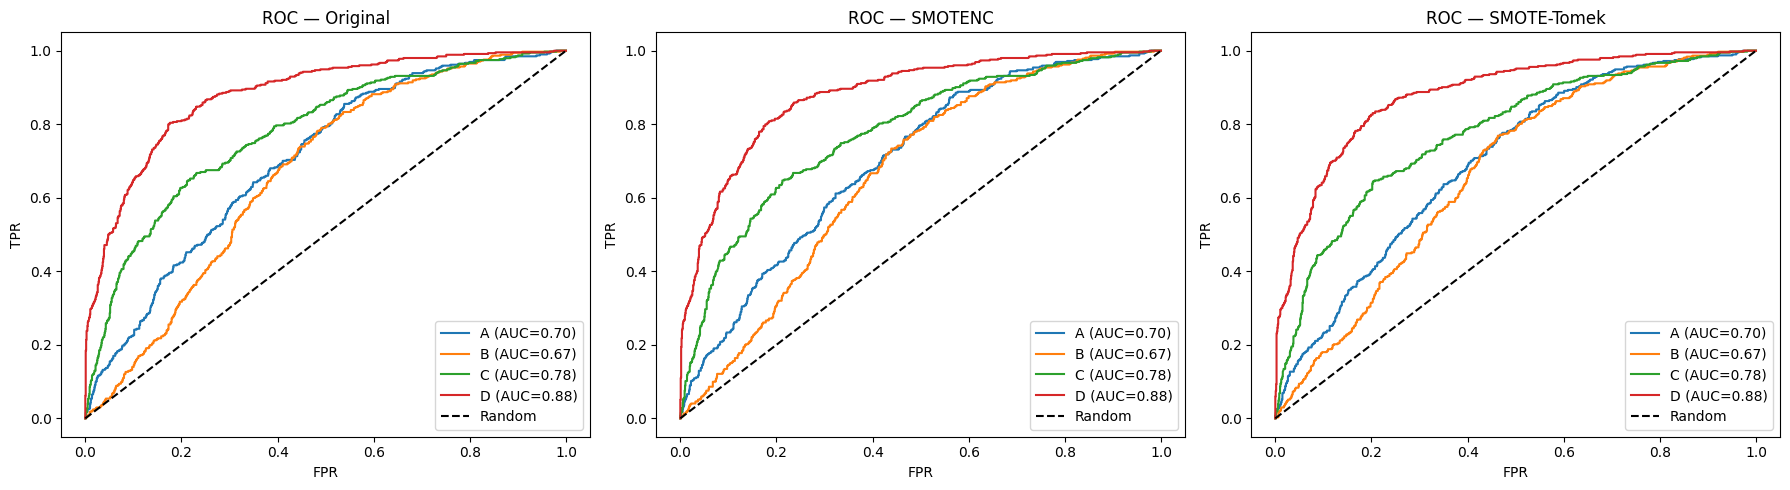

In [53]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = ['A', 'B', 'C', 'D']
y_val_bin = label_binarize(val_targets, classes=classes)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (model_original, 'Original'),
    (model_smote, 'SMOTENC'),
    (model_smotetomek, 'SMOTE-Tomek'),
]

for ax, (model, name) in zip(axes, models):
    val_probs = model.predict_proba(val_inputs)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], val_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_title(f'ROC — {name}')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend()

plt.tight_layout()
plt.show()

**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

#Висновки
Великого ефекту від вирівнювання кількості значень за допомогою smotenc  та smotetomek - не спостерігається, тому що датасет був з самого початку доволі збалансованим.
Найбільш підходяща метрика для оцінки - macro f1-score.
Найбільше покращення показав клас В, але саме цю категорію найваже передбачити